In [1]:
"""Resolve project root dynamically for portable relative imports."""
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "utility.py").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "utility.py").exists():
    raise RuntimeError("Could not locate project root containing utility.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# import utility
import pandas as pd
import kaos

In [3]:
def random_permutation_with_count_preserved(input_string):
    """
    Randomly permute characters while preserving per-character counts.

    Parameters:
        input_string (str): Sequence string to be shuffled.

    Returns:
        str: Shuffled sequence with preserved character frequencies.
    """
    import random

    unique_chars = sorted(set(input_string))
    char_counts = {char: input_string.count(char) for char in unique_chars}

    permuted_chars = []
    for char in unique_chars:
        permuted_chars.extend([char] * char_counts[char])

    random.shuffle(permuted_chars)
    return ''.join(permuted_chars)

In [4]:
"""Define core parameters and input path for the Figure 1f workflow."""
kmer_length = 10
file_path_ecoli = PROJECT_ROOT / "data" / "562.5708.fna"

In [5]:
permuted_string1 = random_permutation_with_count_preserved(kaos.read_fasta(file_path_ecoli))
fcgr_sequence_ecoli_fake = kaos.chaos_frequency_matrix(fasta_string= permuted_string1, kmer_length=kmer_length,  pseudo_count=True)

Text(0.5, 1.0, 'Fake $\\it{E.coli}$ DNA FCGR heatmap')

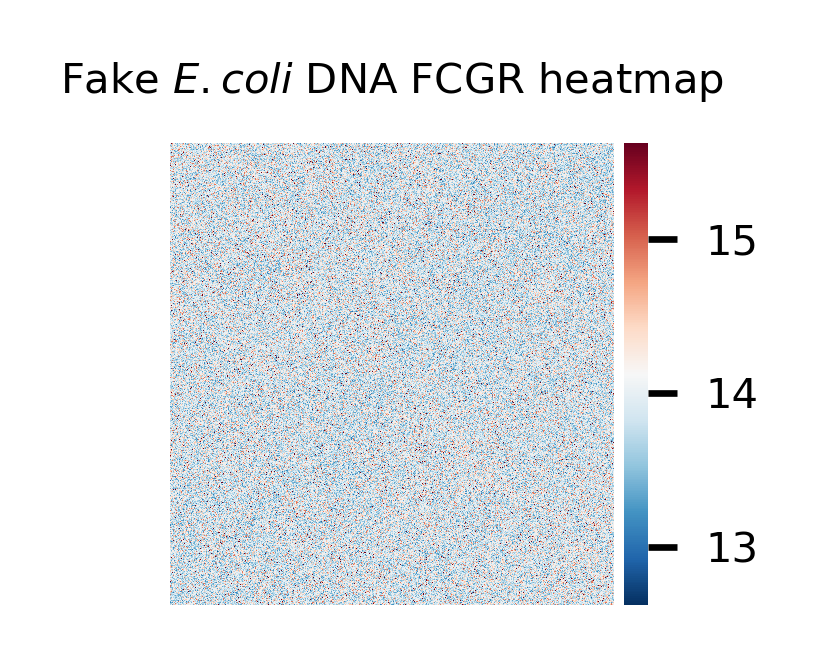

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# import utility

fig, ax = plt.subplots(1, 1, figsize=(1.15, 1), dpi = 600)
heatmap1 =sns.heatmap(-np.log(fcgr_sequence_ecoli_fake[0]/fcgr_sequence_ecoli_fake[0].sum()), ax=ax, cmap= "RdBu_r", cbar_kws={'orientation': 'vertical', 'pad': 0.02})
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_yticks([])
ax.set_xticks([])
# ax.set_title(str(species[counter]))
ax.tick_params(axis='x', labelsize=5, rotation=90)
ax.tick_params(axis='y', labelsize=5)
ax.tick_params(axis='both', which='both', width=0.5)
ax.xaxis.label.set_fontsize(5)
ax.yaxis.label.set_fontsize(5)
ax.title.set_fontsize(5)
cbar1 = heatmap1.collections[0].colorbar
cbar1.ax.yaxis.set_tick_params(labelsize=5)
ax.set_title(None)
title = r"Fake $\it{E.coli}$ DNA FCGR heatmap"

ax.set_title(title, fontsize = 5)
# plt.tight_layout()
# plt.savefig("finalPlots/fake ecoli fcgr.png", dpi = 600)